In [56]:
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


In [57]:
df=pd.read_csv('genesis_weapon_combined.csv')

In [58]:
df.head()

,sample_index,stat_date,character_name,ocid,world_name,level,job,union_level,combat_power,boss_damage_pct,ignore_defense_pct,critical_damage_pct,final_damage_pct,starforce,arcane_force,liberation_quest_clear,genesis_weapon_equipped,genesis_weapon_liberated,destiny_weapon_equipped,destiny_weapon_liberated
0,1,2026-05-06,몽클레어,6c22c4aaa120be4474d7e0a9d420f753efe8d04e6d233b...,엘리시움,299,나이트로드,10283.0,292550716.0,383.0,92.86,137.10,63.19,330.0,1350.0,1,1.0,1,0.0,0.0
1,2,2026-05-06,송재민,3fe9d397814553ed6ceeadae8caa34db,크로아,297,나이트로드,9881.0,190231196.0,346.0,94.13,107.45,63.19,305.0,1370.0,1,1.0,1,0.0,0.0
2,3,2026-05-06,곤주,b41546f8dfb6267651817cd1792c85c8efe8d04e6d233b...,엘리시움,300,"아크메이지(불,독)",10119.0,220450982.0,296.0,93.00,105.60,267.67,280.0,1360.0,1,1.0,1,0.0,0.0
3,4,2026-05-06,희야아부지,c404c490470c36429e89c95843679e9d,스카니아,296,듀얼블레이더,9949.0,537930825.0,499.0,96.50,115.75,55.39,432.0,1360.0,1,1.0,1,0.0,0.0
4,5,2026-05-06,챌리,acea2d2223273b935505888453660058,스카니아,298,"아크메이지(썬,콜)",10810.0,328725061.0,390.0,96.27,91.45,194.14,336.0,1380.0,2,0.0,1,1.0,1.0


In [59]:
df.columns

Index(['sample_index', 'stat_date', 'character_name', 'ocid', 'world_name',
       'level', 'job', 'union_level', 'combat_power', 'boss_damage_pct',
       'ignore_defense_pct', 'critical_damage_pct', 'final_damage_pct',
       'starforce', 'arcane_force', 'liberation_quest_clear',
       'genesis_weapon_equipped', 'genesis_weapon_liberated',
       'destiny_weapon_equipped', 'destiny_weapon_liberated'],
      dtype='str')

In [60]:
cols=['sample_index', 'stat_date', 'character_name', 'ocid', 'liberation_quest_clear','genesis_weapon_equipped','destiny_weapon_equipped', 'destiny_weapon_liberated']
#'AP 배분 STR','AP 배분 DEX', 'AP 배분 INT', 'AP 배분 LUK'

In [61]:
for col in cols:
    df = df.drop([col], axis=1)

In [62]:
df.head()

,world_name,level,job,union_level,combat_power,boss_damage_pct,ignore_defense_pct,critical_damage_pct,final_damage_pct,starforce,arcane_force,genesis_weapon_liberated
0,엘리시움,299,나이트로드,10283.0,292550716.0,383.0,92.86,137.10,63.19,330.0,1350.0,1
1,크로아,297,나이트로드,9881.0,190231196.0,346.0,94.13,107.45,63.19,305.0,1370.0,1
2,엘리시움,300,"아크메이지(불,독)",10119.0,220450982.0,296.0,93.00,105.60,267.67,280.0,1360.0,1
3,스카니아,296,듀얼블레이더,9949.0,537930825.0,499.0,96.50,115.75,55.39,432.0,1360.0,1
4,스카니아,298,"아크메이지(썬,콜)",10810.0,328725061.0,390.0,96.27,91.45,194.14,336.0,1380.0,1


In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   world_name                360 non-null    str    
 1   level                     360 non-null    int64  
 2   job                       360 non-null    str    
 3   union_level               339 non-null    float64
 4   combat_power              360 non-null    float64
 5   boss_damage_pct           360 non-null    float64
 6   ignore_defense_pct        360 non-null    float64
 7   critical_damage_pct       360 non-null    float64
 8   final_damage_pct          360 non-null    float64
 9   starforce                 360 non-null    float64
 10  arcane_force              360 non-null    float64
 11  genesis_weapon_liberated  360 non-null    int64  
dtypes: float64(8), int64(2), str(2)
memory usage: 41.2 KB


In [64]:
df.describe()

,level,union_level,combat_power,boss_damage_pct,ignore_defense_pct,critical_damage_pct,final_damage_pct,starforce,arcane_force,genesis_weapon_liberated
count,360.000000,339.000000,3.600000e+02,360.000000,360.00000,360.000000,360.000000,360.000000,360.000000,360.000000
mean,292.266667,9879.041298,3.065471e+08,386.150000,92.56825,112.378611,105.016528,312.075000,1314.652778,0.913889
std,14.641910,1935.934482,2.483831e+08,119.263594,8.20687,30.701478,65.435127,88.461958,207.533812,0.280918
min,200.000000,210.000000,7.597000e+03,0.000000,20.40000,10.000000,14.400000,0.000000,40.000000,0.000000
25%,295.000000,9866.000000,1.543425e+08,317.750000,91.86000,99.237500,60.880000,276.500000,1350.000000,1.000000
50%,296.000000,10268.000000,2.419458e+08,383.500000,94.77000,116.025000,80.880000,310.000000,1360.000000,1.000000
75%,297.000000,10790.000000,3.741885e+08,463.500000,96.68000,130.875000,124.800000,371.000000,1370.000000,1.000000
max,300.000000,11192.000000,1.475954e+09,691.000000,99.04000,200.300000,393.800000,469.000000,1460.000000,1.000000


In [65]:
df.describe(exclude=np.number)

,world_name,job
count,360,360
unique,13,47
top,엘리시움,비숍
freq,74,27


In [66]:
df.isnull().isnull().sum()

world_name                  0
level                       0
job                         0
union_level                 0
combat_power                0
boss_damage_pct             0
ignore_defense_pct          0
critical_damage_pct         0
final_damage_pct            0
starforce                   0
arcane_force                0
genesis_weapon_liberated    0
dtype: int64

In [67]:
df["union_level"] = df["union_level"].fillna(0)

In [68]:
df.isnull().isnull().sum()

world_name                  0
level                       0
job                         0
union_level                 0
combat_power                0
boss_damage_pct             0
ignore_defense_pct          0
critical_damage_pct         0
final_damage_pct            0
starforce                   0
arcane_force                0
genesis_weapon_liberated    0
dtype: int64

In [69]:
df['world_name'].unique()

<ArrowStringArray>
['엘리시움',  '크로아', '스카니아',   '베라',  '제니스',   '레드', '이노시스',   '루나',  '오로라',
  '유니온',  '아케인',  '에오스', '핼리오스']
Length: 13, dtype: str

In [70]:
df['job'].unique()

<ArrowStringArray>
[     '나이트로드', '아크메이지(불,독)',     '듀얼블레이더', '아크메이지(썬,콜)',      '캐논마스터',
      '데몬어벤져',      '스트라이커',         '비숍',      '다크나이트',         '아델',
        '섀도어',        '히어로',         '아란',        '카데나',     '플레임위자드',
         '카인',      '배틀메이지',      '패스파인더',        '바이퍼',      '와일드헌터',
         '제로',      '소울마스터',       '키네시스',         '은월',         '팬텀',
     '윈드브레이커',     '데몬슬레이어',         '아크',         '에반',       '루미너스',
     '엔젤릭버스터',         '제논',      '나이트워커',       '블래스터',        '팔라딘',
      '메르세데스',         '호영',          '렌',      '보우마스터',         '신궁',
         '캡틴',        '미하일',        '일리움',         '칼리',         '라라',
        '카이저',        '메카닉']
Length: 47, dtype: str

In [71]:
df.columns

Index(['world_name', 'level', 'job', 'union_level', 'combat_power',
       'boss_damage_pct', 'ignore_defense_pct', 'critical_damage_pct',
       'final_damage_pct', 'starforce', 'arcane_force',
       'genesis_weapon_liberated'],
      dtype='str')

In [72]:
import matplotlib.pyplot as plt 
import seaborn as sns

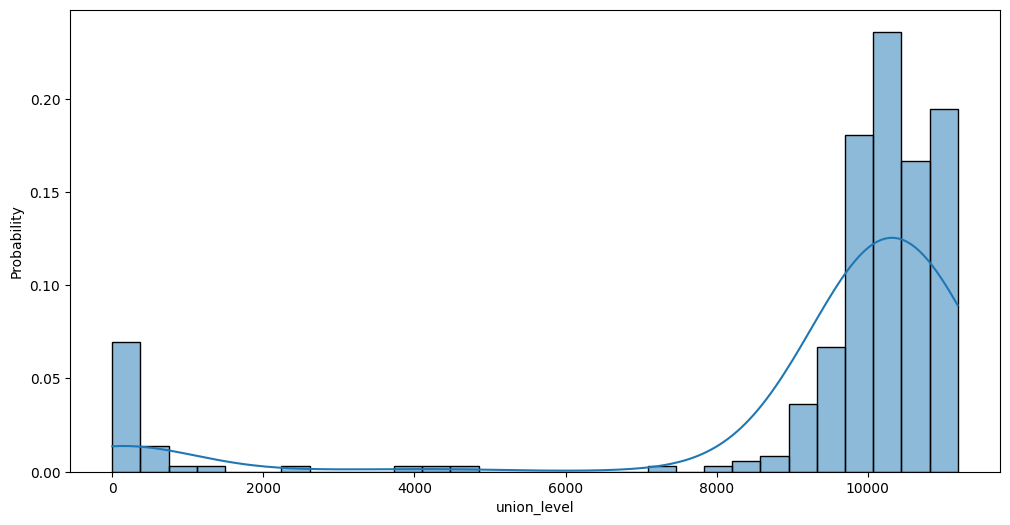

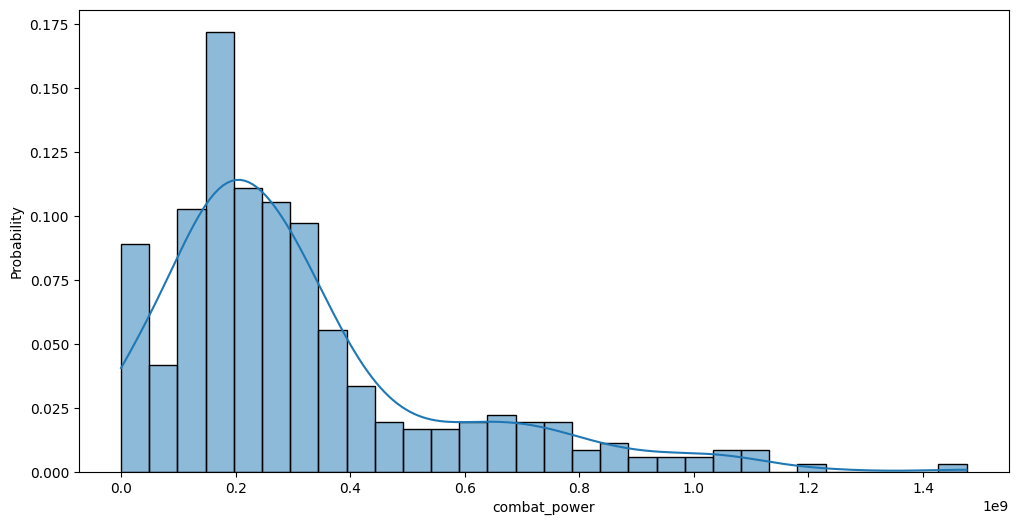

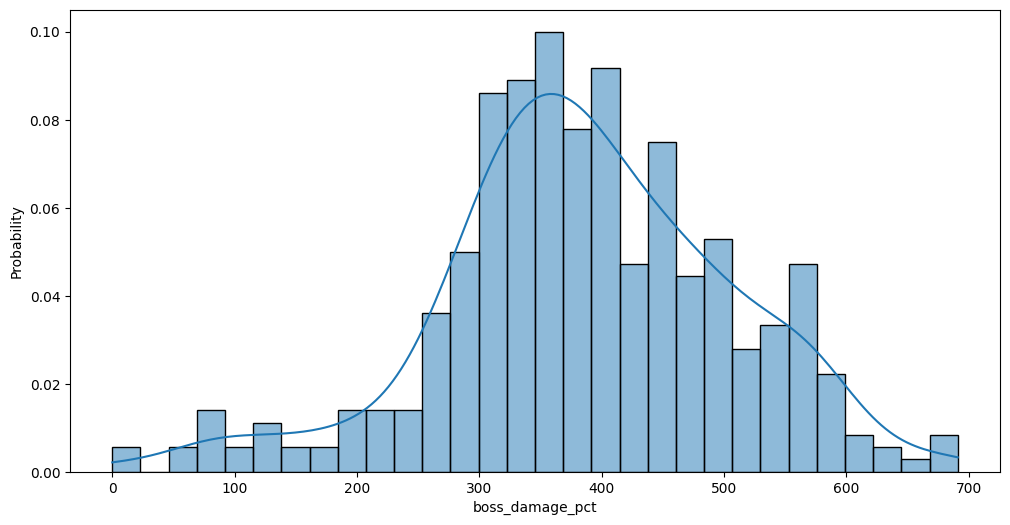

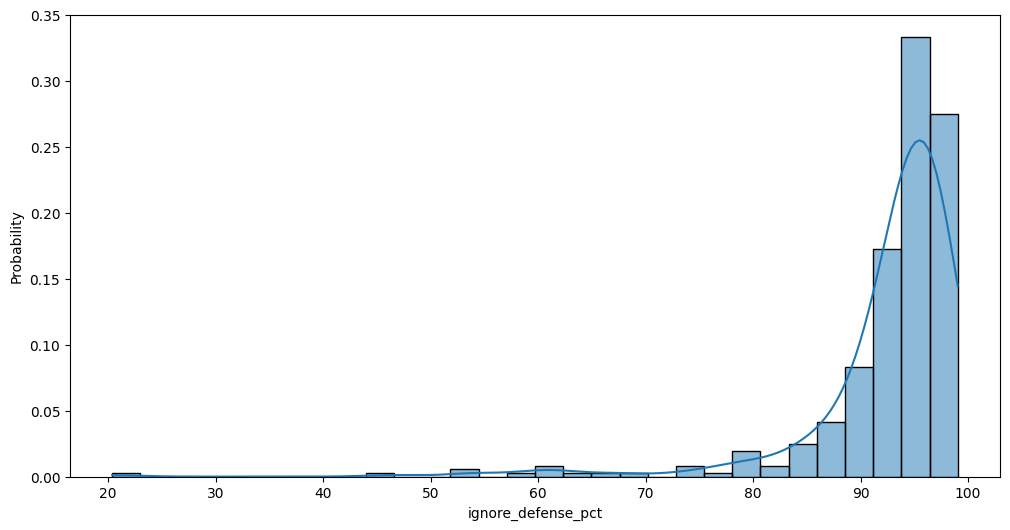

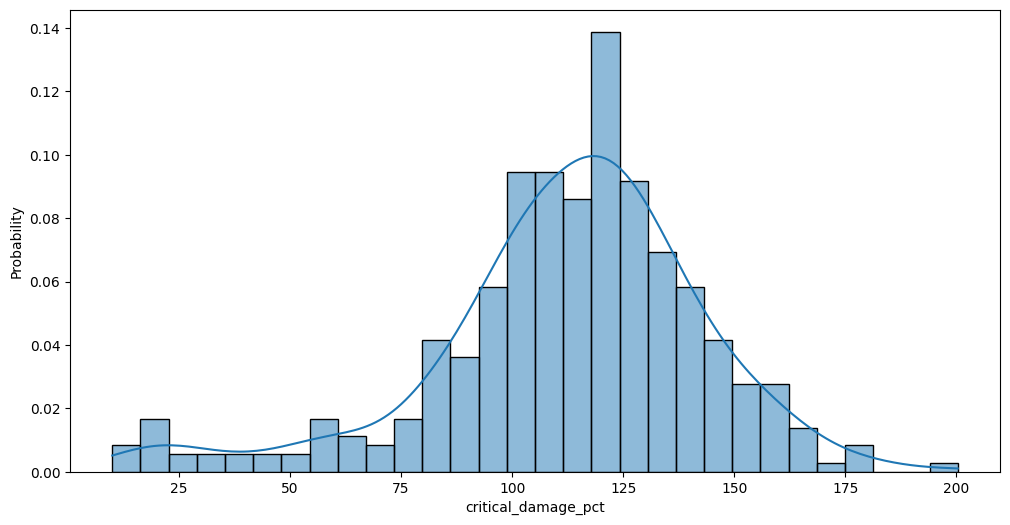

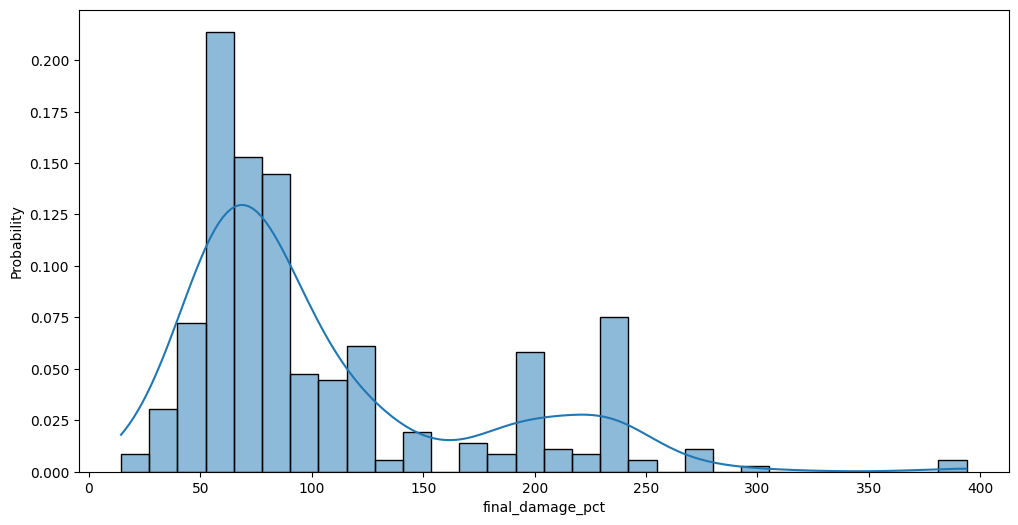

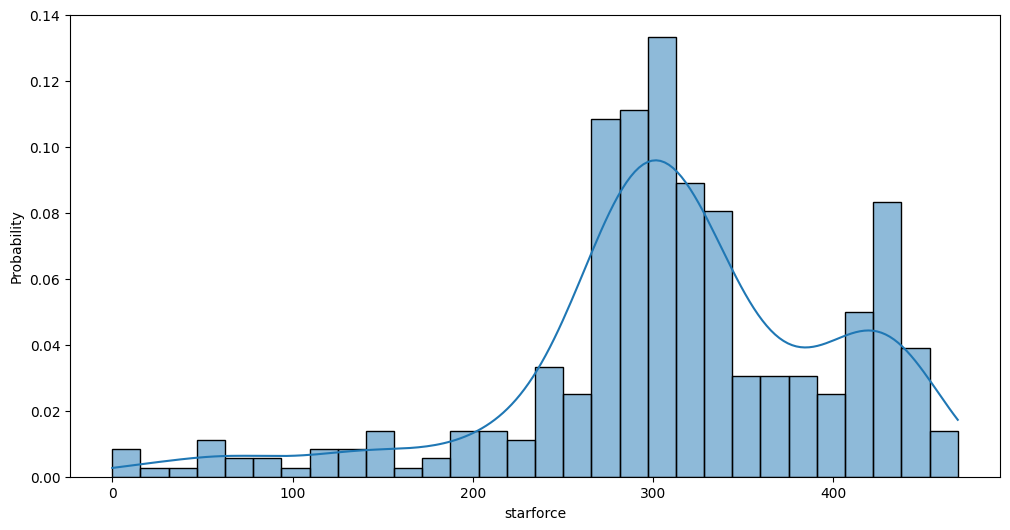

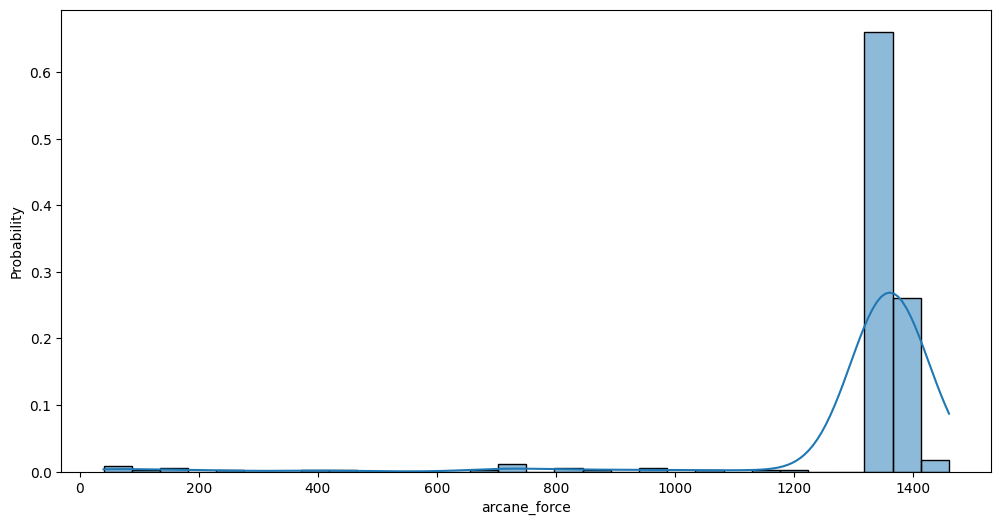

In [73]:
for col in ['union_level', 'combat_power',
       'boss_damage_pct', 'ignore_defense_pct', 'critical_damage_pct',
       'final_damage_pct', 'starforce', 'arcane_force']:
  plt.figure(figsize=(12, 6))
  sns.histplot(data=df, x=col,bins=30,kde=True,stat='probability')

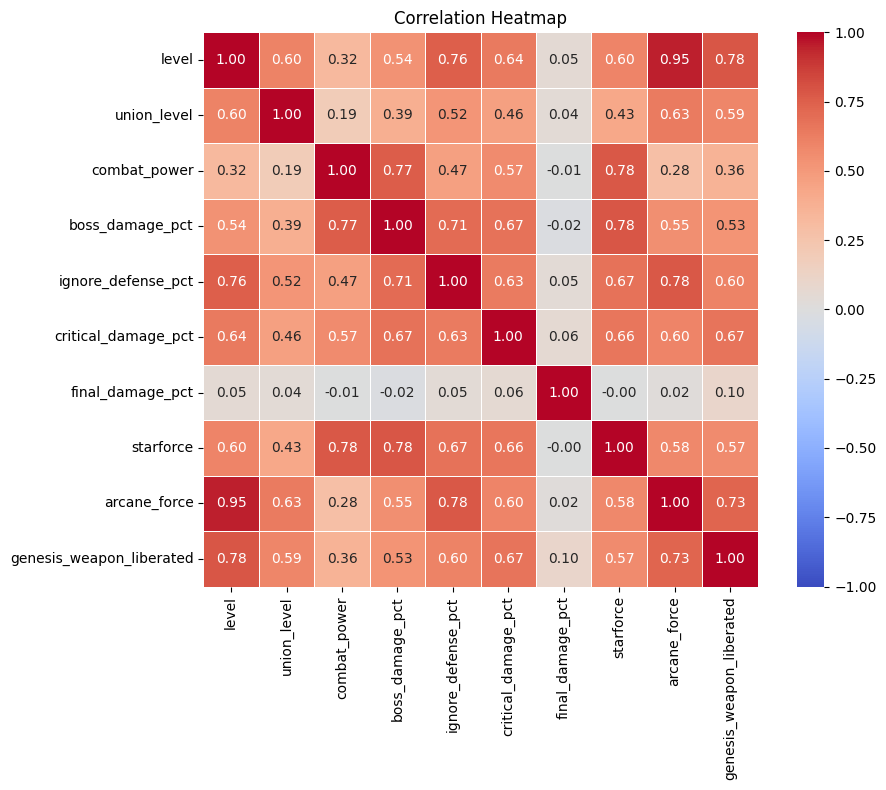

In [76]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,       # 셀 안에 숫자 표시
    fmt='.2f',        # 소수점 2자리
    cmap='coolwarm',  # 파랑(음)~빨강(양) 색상
    center=0,         # 0 기준으로 색 중앙
    vmin=-1, vmax=1,
    square=True,      # 정사각형 셀
    linewidths=0.5
)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [80]:
arrs = ['union_level', 'combat_power',
       'boss_damage_pct', 'ignore_defense_pct', 'critical_damage_pct',
       'final_damage_pct', 'starforce', 'arcane_force']
for x in range(len(arrs)):
    for y in range(len(arrs)):
        if x != y:
            print(f"sns.relplot(data=df, x=\"{arrs[x]}\", y=\"{arrs[y]}\", kind=\"scatter\")")

sns.relplot(data=df, x="union_level", y="combat_power", kind="scatter")
sns.relplot(data=df, x="union_level", y="boss_damage_pct", kind="scatter")
sns.relplot(data=df, x="union_level", y="ignore_defense_pct", kind="scatter")
sns.relplot(data=df, x="union_level", y="critical_damage_pct", kind="scatter")
sns.relplot(data=df, x="union_level", y="final_damage_pct", kind="scatter")
sns.relplot(data=df, x="union_level", y="starforce", kind="scatter")
sns.relplot(data=df, x="union_level", y="arcane_force", kind="scatter")
sns.relplot(data=df, x="combat_power", y="union_level", kind="scatter")
sns.relplot(data=df, x="combat_power", y="boss_damage_pct", kind="scatter")
sns.relplot(data=df, x="combat_power", y="ignore_defense_pct", kind="scatter")
sns.relplot(data=df, x="combat_power", y="critical_damage_pct", kind="scatter")
sns.relplot(data=df, x="combat_power", y="final_damage_pct", kind="scatter")
sns.relplot(data=df, x="combat_power", y="starforce", kind="scatter")
sns.relplot(data=df, x="c

c:\Dev\project\SKN27-3rd-1TEAM\.venv\Lib\site-packages\seaborn\axisgrid.py:453: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=figsize)


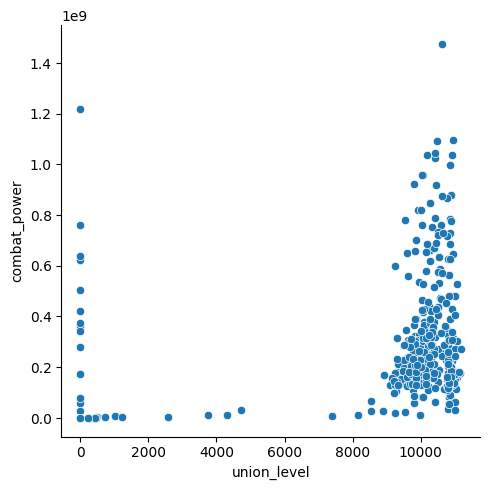

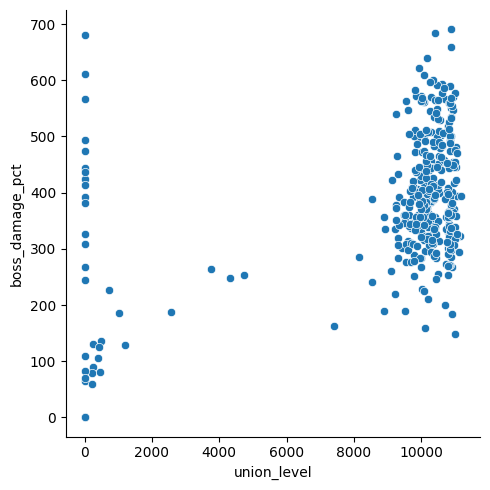

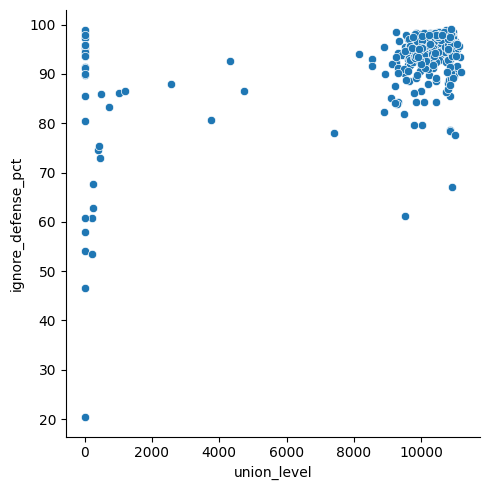

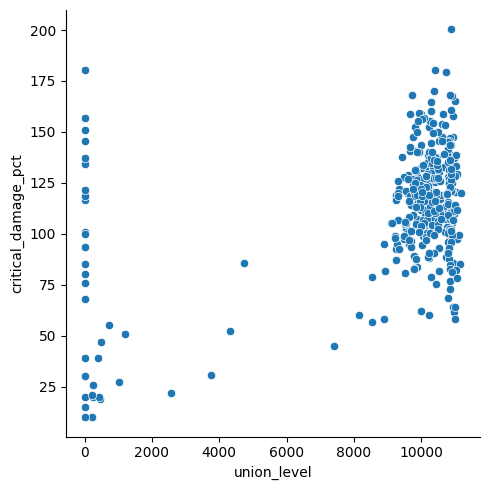

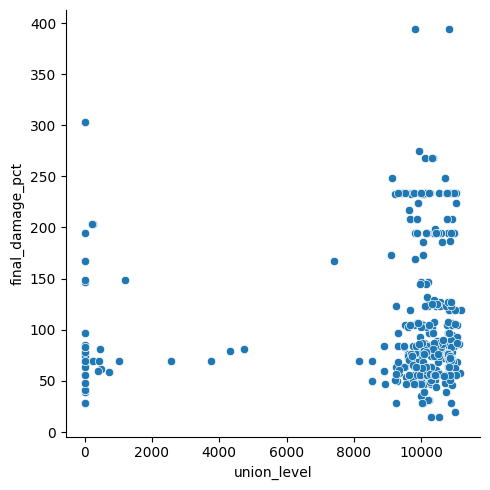

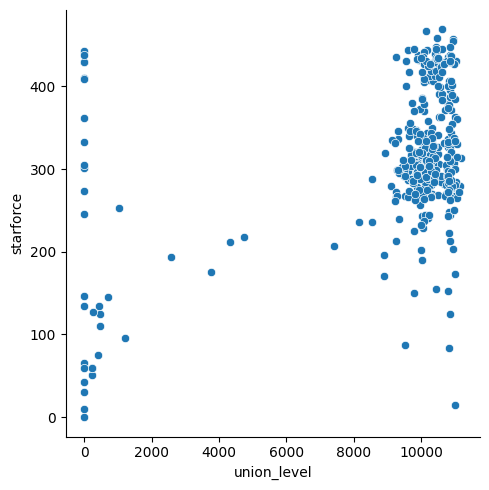

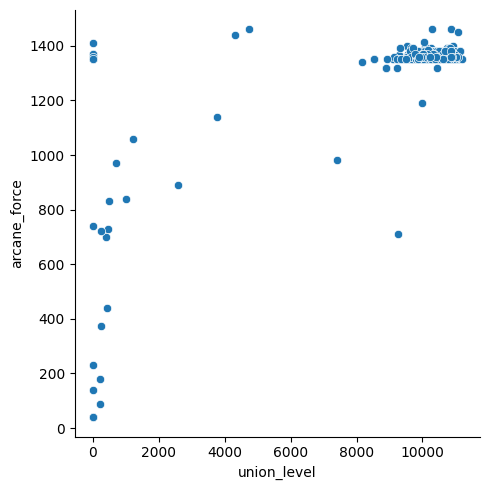

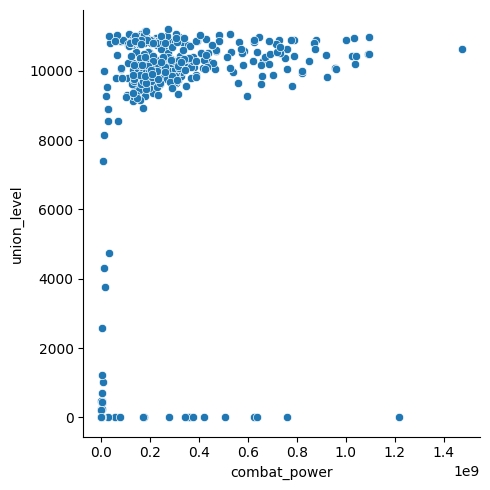

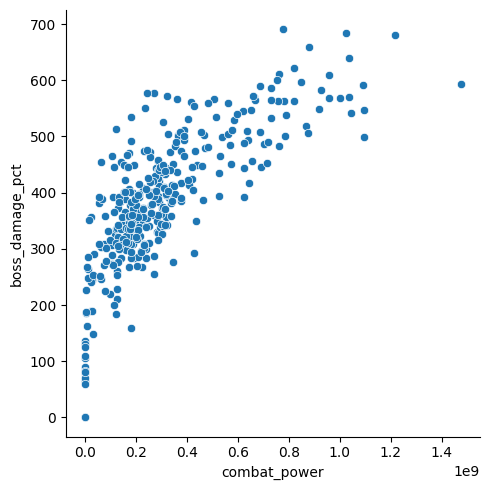

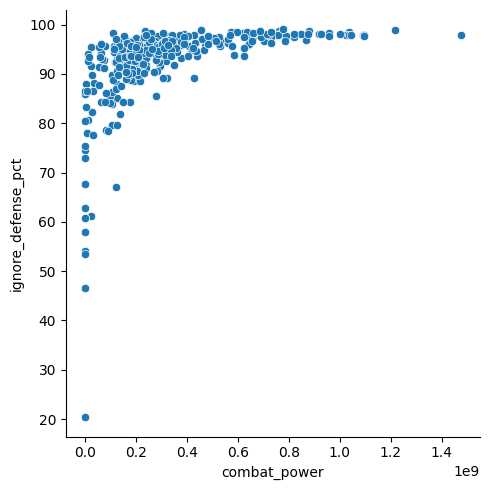

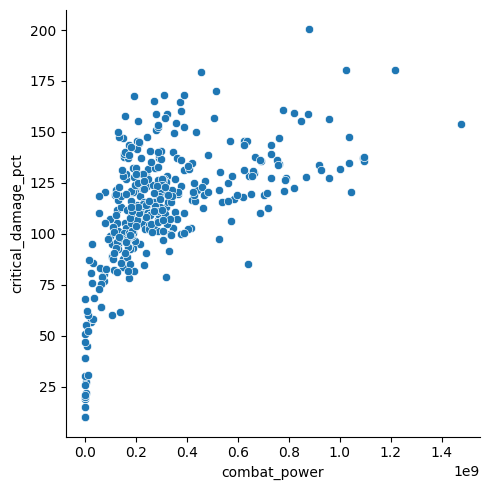

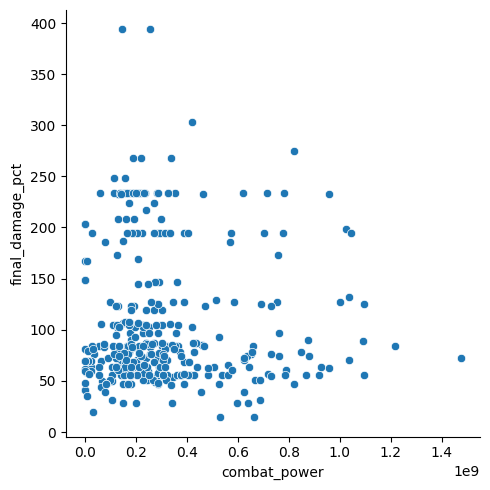

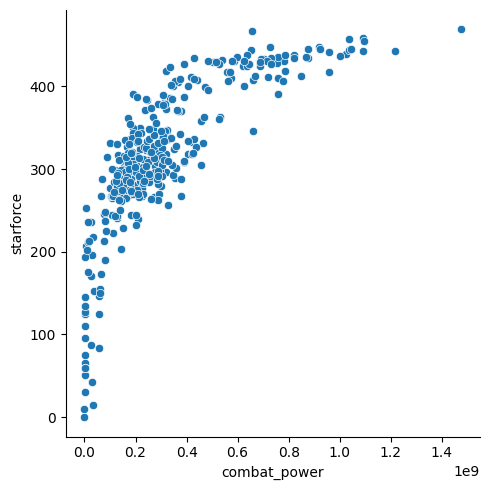

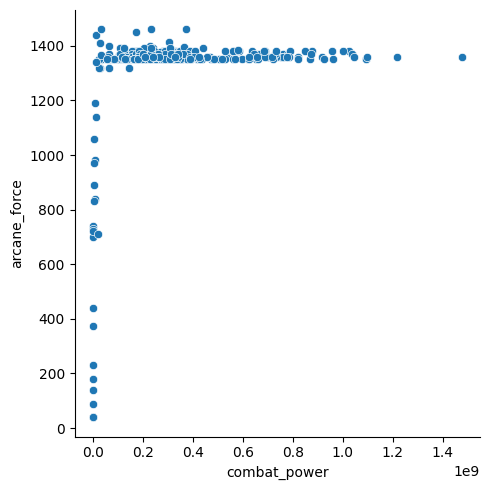

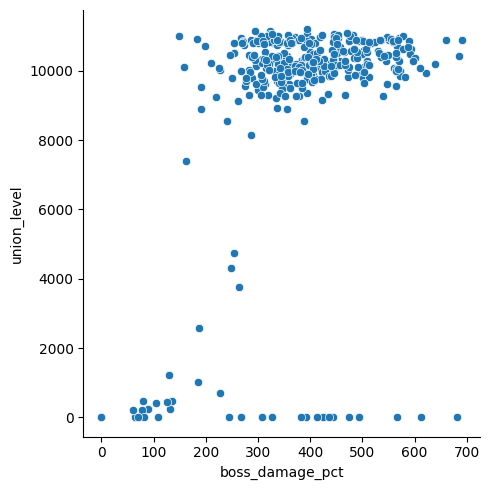

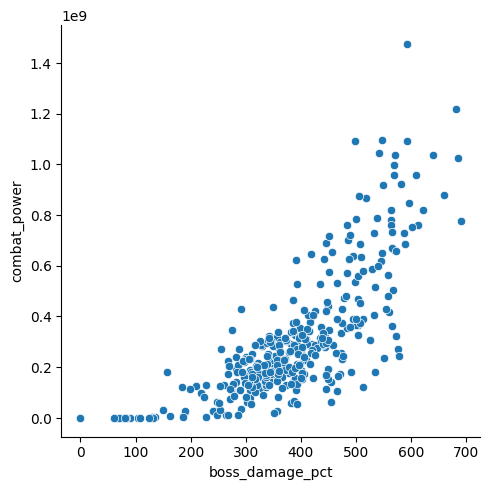

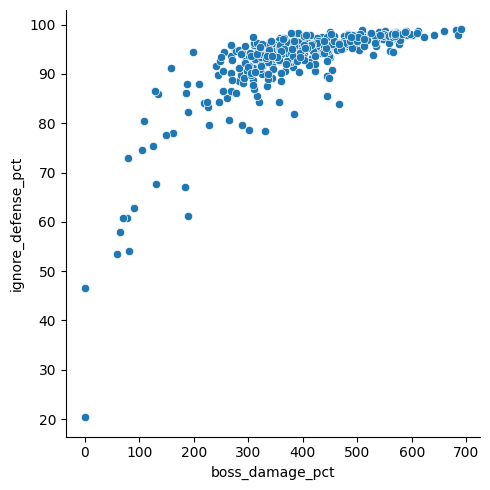

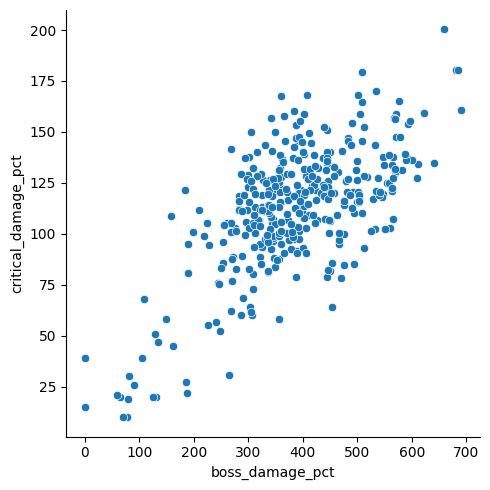

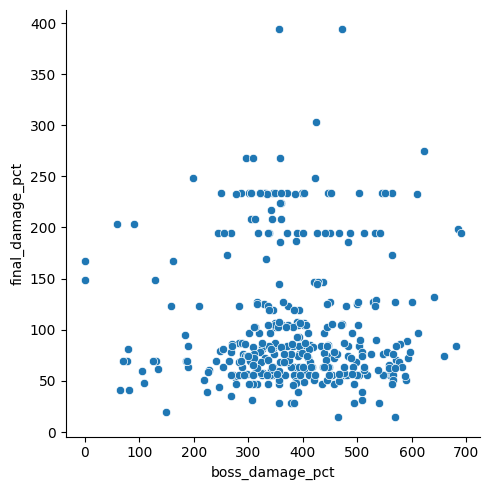

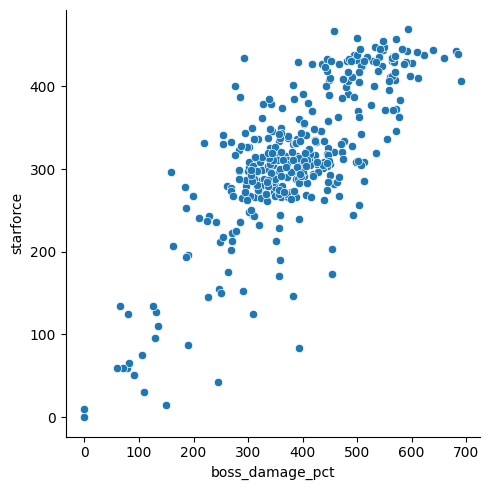

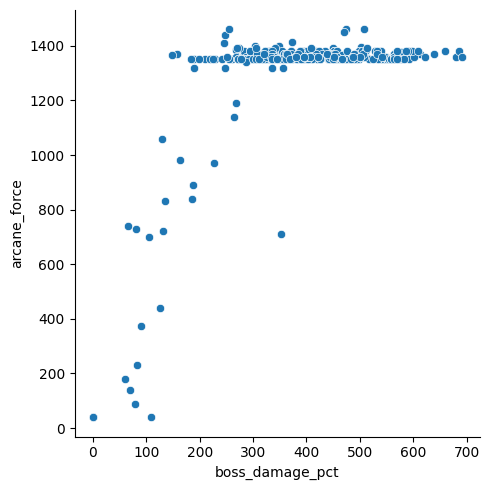

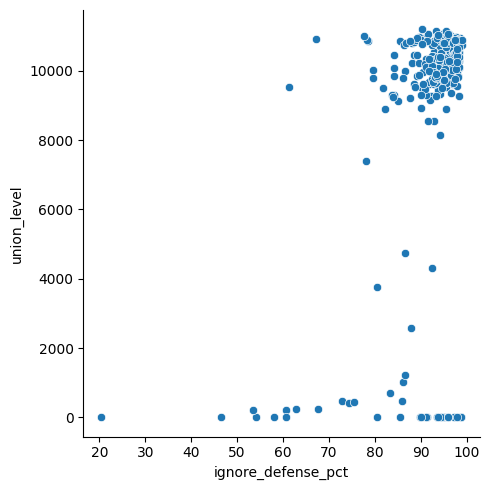

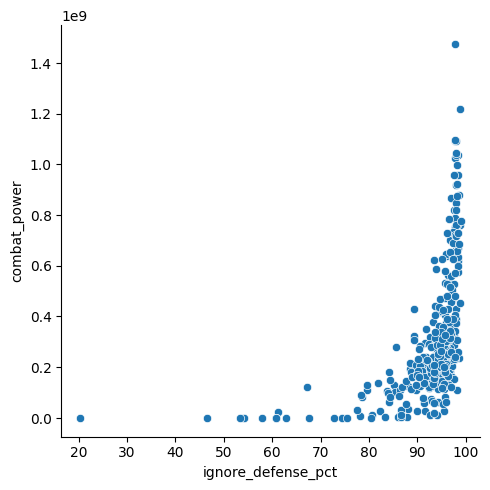

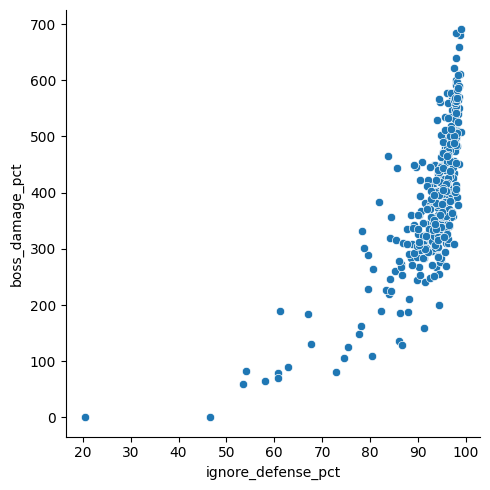

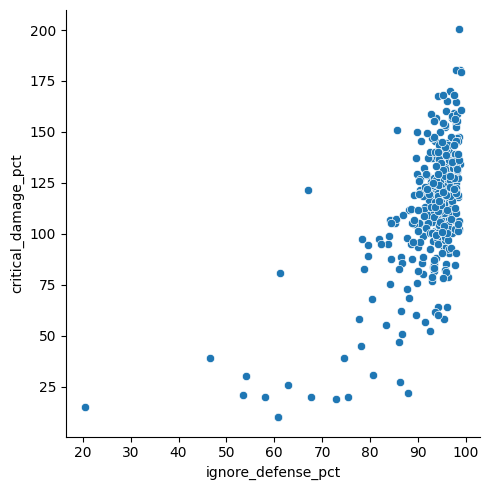

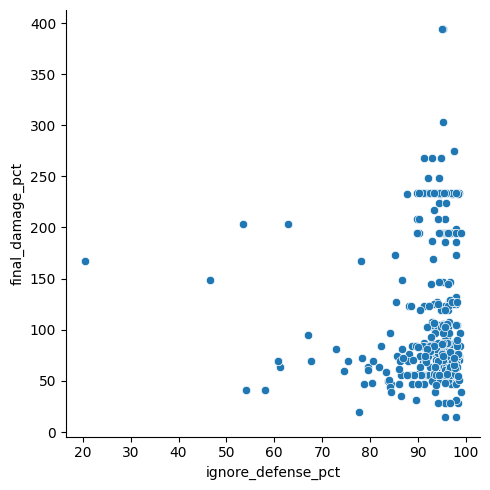

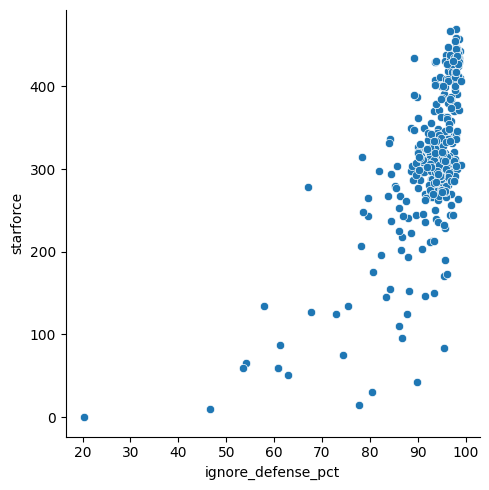

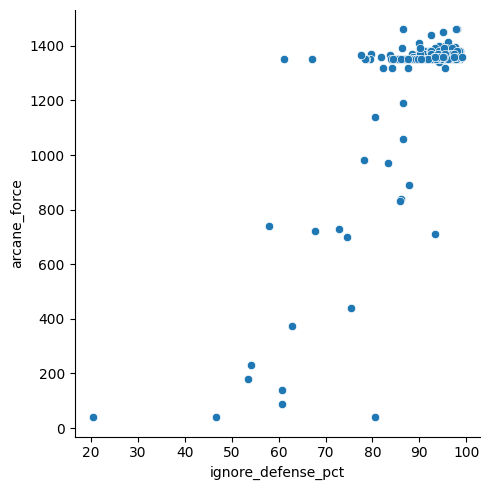

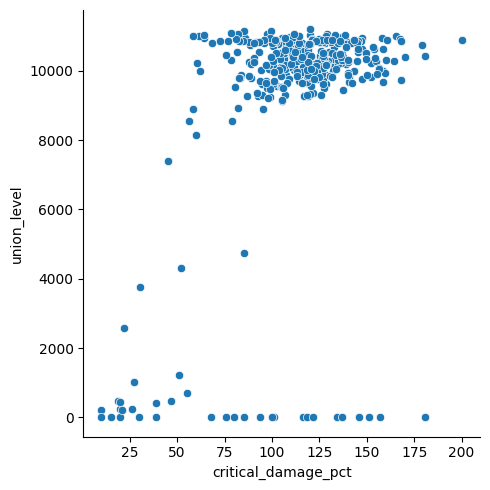

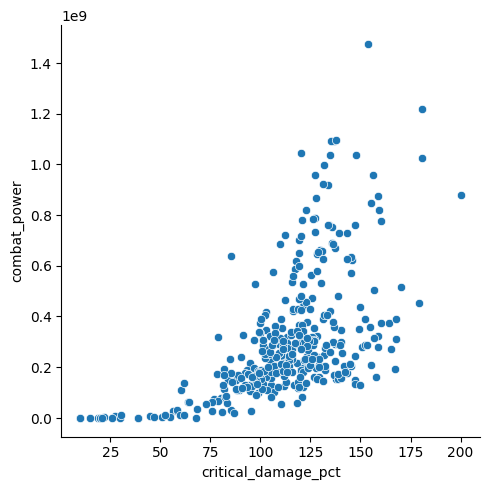

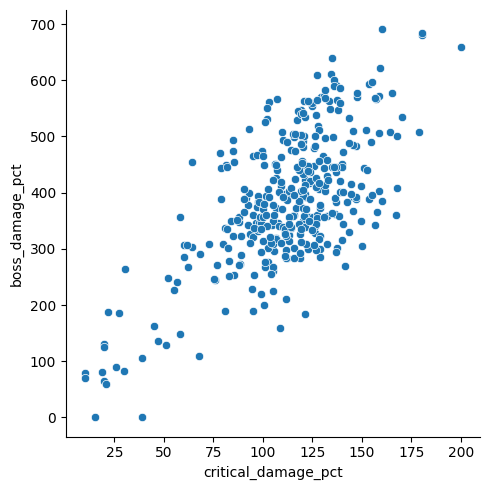

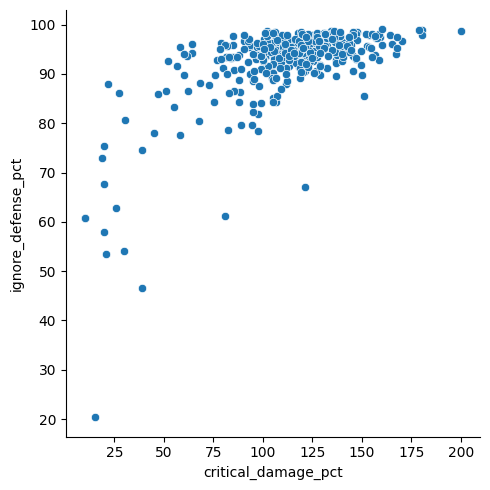

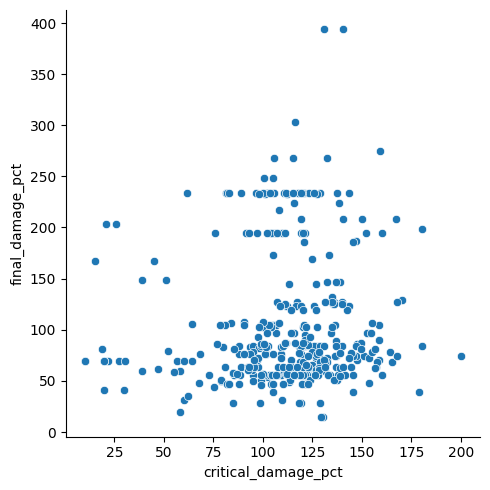

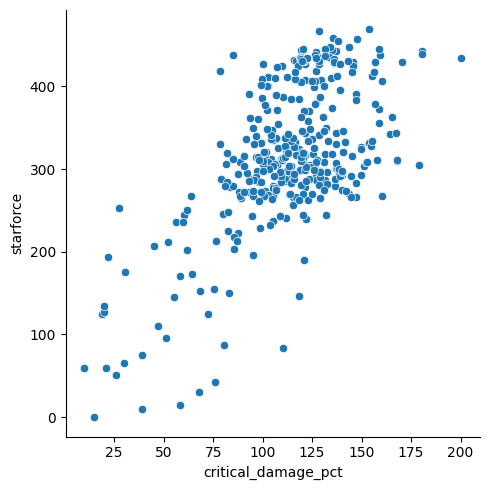

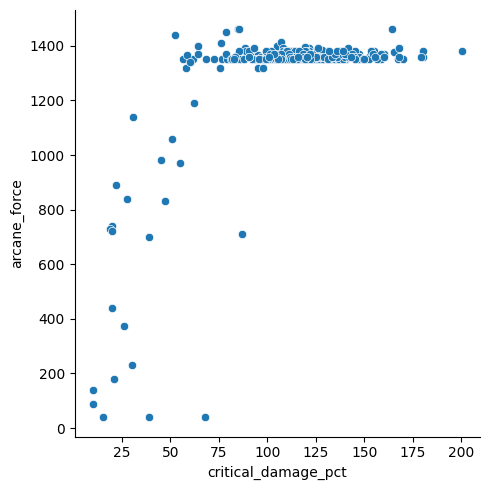

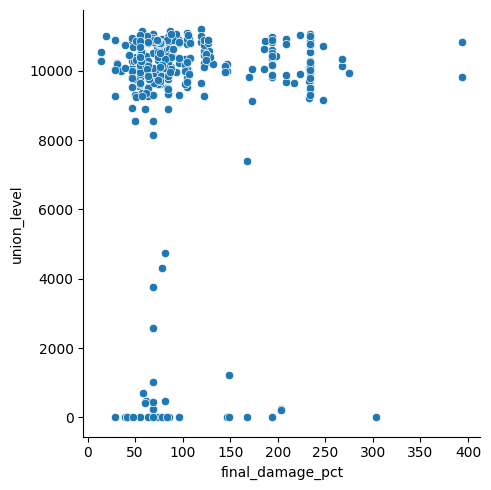

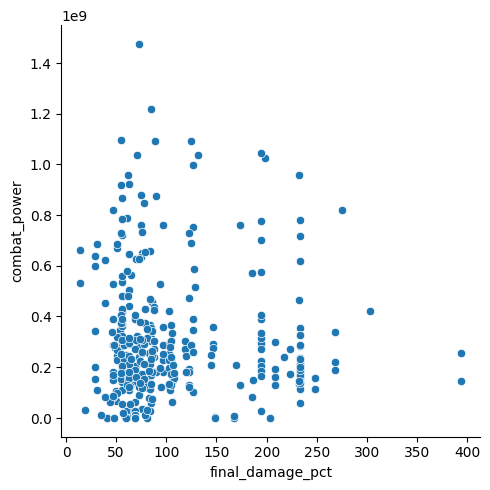

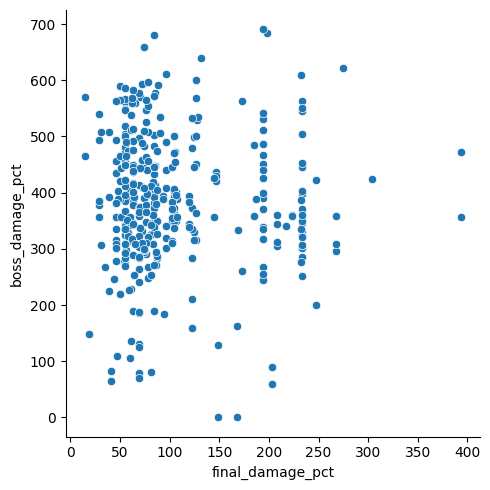

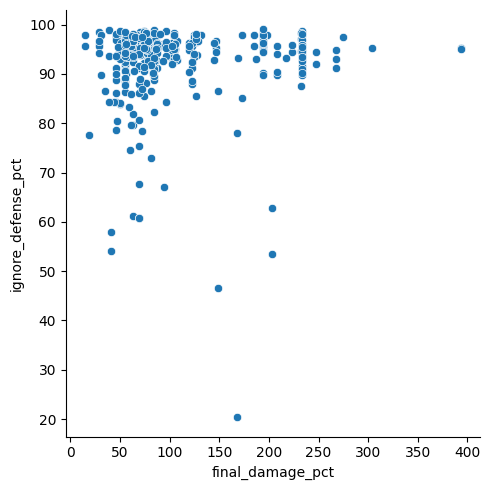

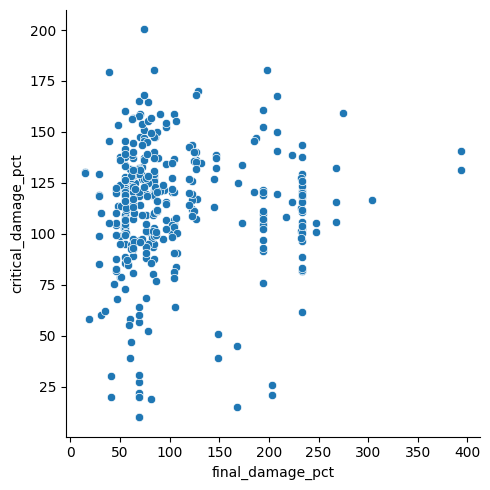

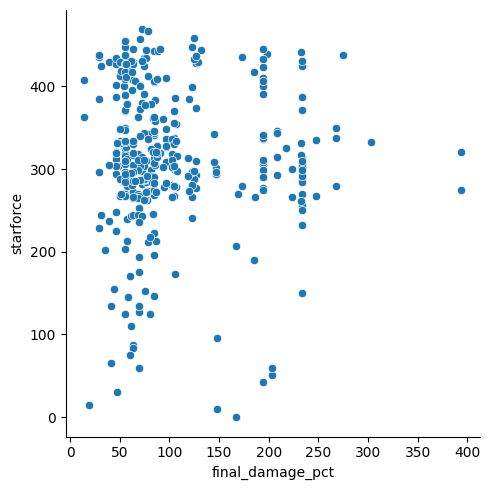

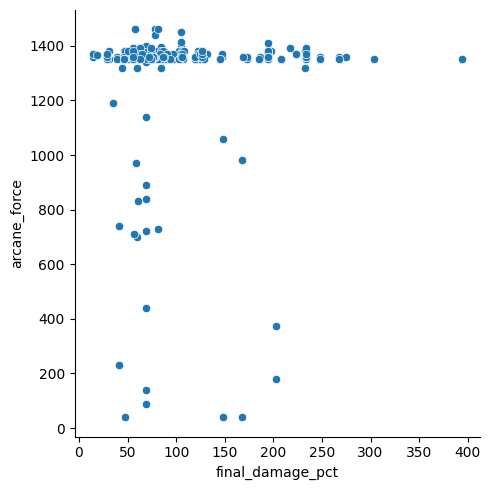

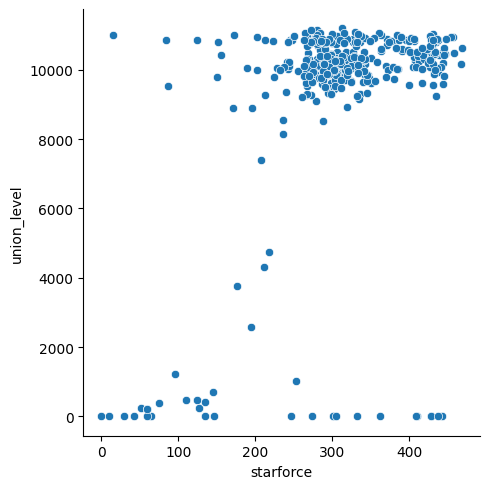

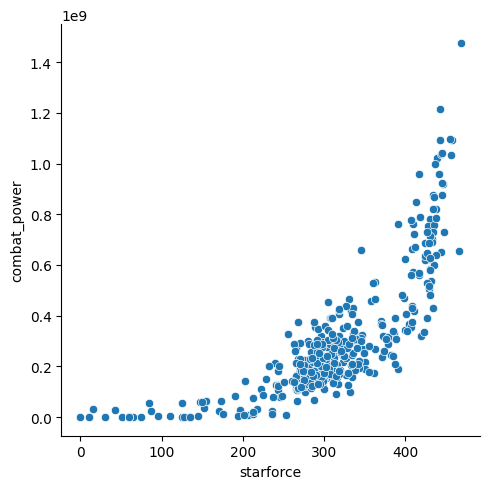

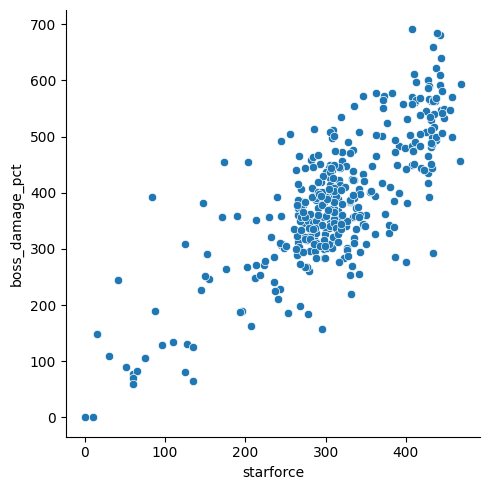

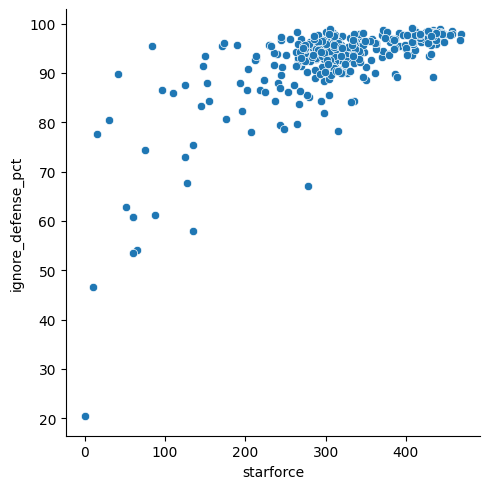

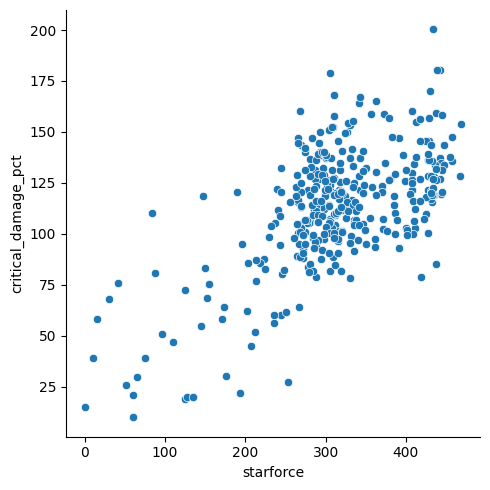

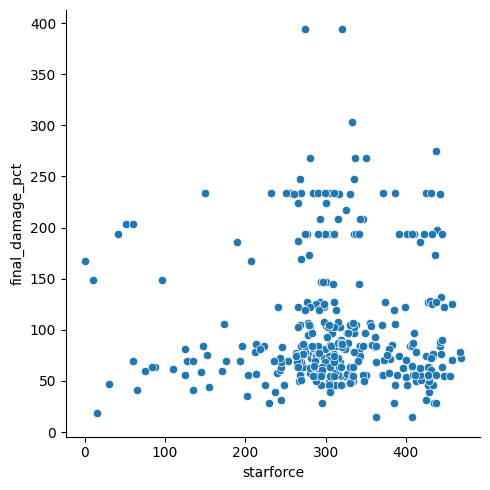

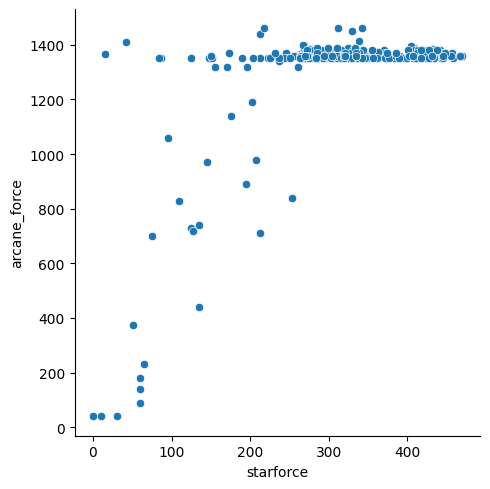

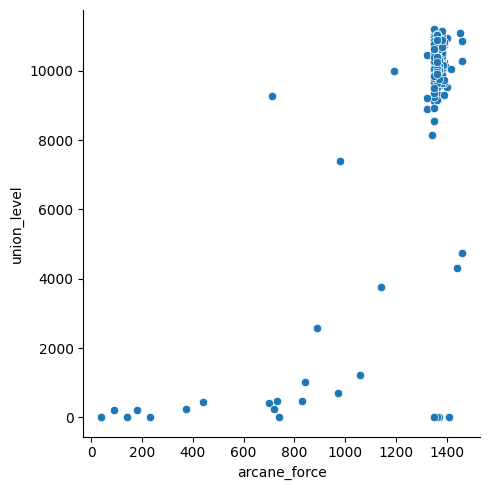

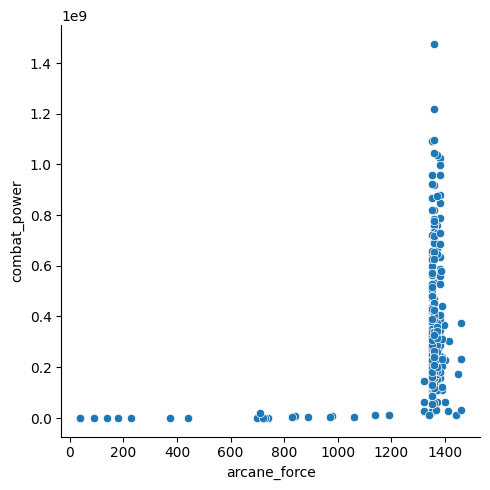

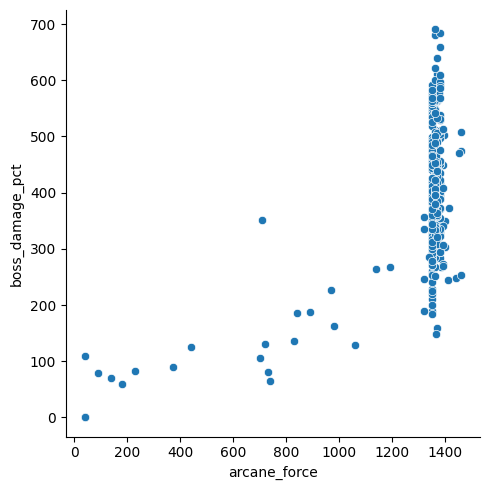

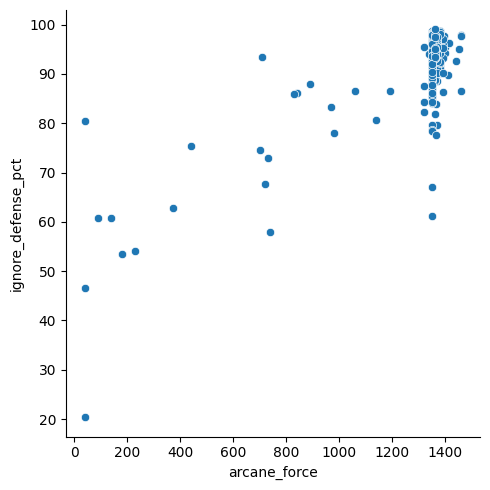

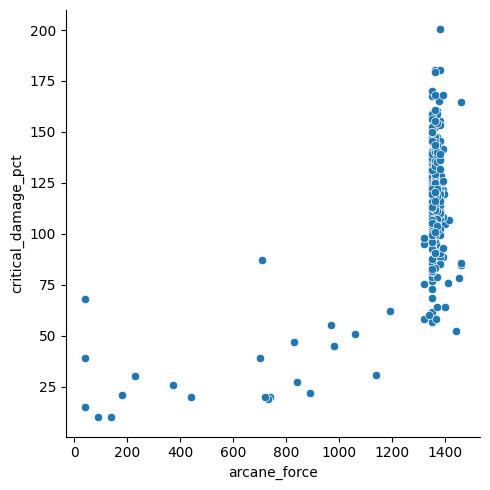

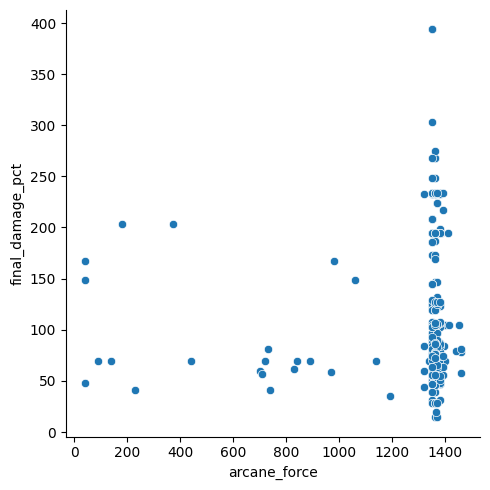

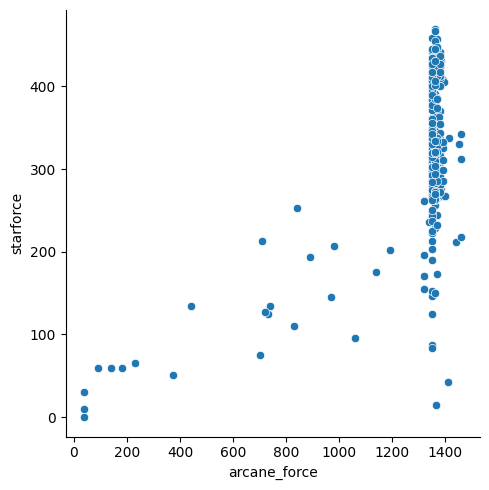

In [81]:
sns.relplot(data=df, x="union_level", y="combat_power", kind="scatter")
sns.relplot(data=df, x="union_level", y="boss_damage_pct", kind="scatter")
sns.relplot(data=df, x="union_level", y="ignore_defense_pct", kind="scatter")
sns.relplot(data=df, x="union_level", y="critical_damage_pct", kind="scatter")
sns.relplot(data=df, x="union_level", y="final_damage_pct", kind="scatter")
sns.relplot(data=df, x="union_level", y="starforce", kind="scatter")
sns.relplot(data=df, x="union_level", y="arcane_force", kind="scatter")
sns.relplot(data=df, x="combat_power", y="union_level", kind="scatter")
sns.relplot(data=df, x="combat_power", y="boss_damage_pct", kind="scatter")
sns.relplot(data=df, x="combat_power", y="ignore_defense_pct", kind="scatter")
sns.relplot(data=df, x="combat_power", y="critical_damage_pct", kind="scatter")
sns.relplot(data=df, x="combat_power", y="final_damage_pct", kind="scatter")
sns.relplot(data=df, x="combat_power", y="starforce", kind="scatter")
sns.relplot(data=df, x="combat_power", y="arcane_force", kind="scatter")
sns.relplot(data=df, x="boss_damage_pct", y="union_level", kind="scatter")
sns.relplot(data=df, x="boss_damage_pct", y="combat_power", kind="scatter")
sns.relplot(data=df, x="boss_damage_pct", y="ignore_defense_pct", kind="scatter")
sns.relplot(data=df, x="boss_damage_pct", y="critical_damage_pct", kind="scatter")
sns.relplot(data=df, x="boss_damage_pct", y="final_damage_pct", kind="scatter")
sns.relplot(data=df, x="boss_damage_pct", y="starforce", kind="scatter")
sns.relplot(data=df, x="boss_damage_pct", y="arcane_force", kind="scatter")
sns.relplot(data=df, x="ignore_defense_pct", y="union_level", kind="scatter")
sns.relplot(data=df, x="ignore_defense_pct", y="combat_power", kind="scatter")
sns.relplot(data=df, x="ignore_defense_pct", y="boss_damage_pct", kind="scatter")
sns.relplot(data=df, x="ignore_defense_pct", y="critical_damage_pct", kind="scatter")
sns.relplot(data=df, x="ignore_defense_pct", y="final_damage_pct", kind="scatter")
sns.relplot(data=df, x="ignore_defense_pct", y="starforce", kind="scatter")
sns.relplot(data=df, x="ignore_defense_pct", y="arcane_force", kind="scatter")
sns.relplot(data=df, x="critical_damage_pct", y="union_level", kind="scatter")
sns.relplot(data=df, x="critical_damage_pct", y="combat_power", kind="scatter")
sns.relplot(data=df, x="critical_damage_pct", y="boss_damage_pct", kind="scatter")
sns.relplot(data=df, x="critical_damage_pct", y="ignore_defense_pct", kind="scatter")
sns.relplot(data=df, x="critical_damage_pct", y="final_damage_pct", kind="scatter")
sns.relplot(data=df, x="critical_damage_pct", y="starforce", kind="scatter")
sns.relplot(data=df, x="critical_damage_pct", y="arcane_force", kind="scatter")
sns.relplot(data=df, x="final_damage_pct", y="union_level", kind="scatter")
sns.relplot(data=df, x="final_damage_pct", y="combat_power", kind="scatter")
sns.relplot(data=df, x="final_damage_pct", y="boss_damage_pct", kind="scatter")
sns.relplot(data=df, x="final_damage_pct", y="ignore_defense_pct", kind="scatter")
sns.relplot(data=df, x="final_damage_pct", y="critical_damage_pct", kind="scatter")
sns.relplot(data=df, x="final_damage_pct", y="starforce", kind="scatter")
sns.relplot(data=df, x="final_damage_pct", y="arcane_force", kind="scatter")
sns.relplot(data=df, x="starforce", y="union_level", kind="scatter")
sns.relplot(data=df, x="starforce", y="combat_power", kind="scatter")
sns.relplot(data=df, x="starforce", y="boss_damage_pct", kind="scatter")
sns.relplot(data=df, x="starforce", y="ignore_defense_pct", kind="scatter")
sns.relplot(data=df, x="starforce", y="critical_damage_pct", kind="scatter")
sns.relplot(data=df, x="starforce", y="final_damage_pct", kind="scatter")
sns.relplot(data=df, x="starforce", y="arcane_force", kind="scatter")
sns.relplot(data=df, x="arcane_force", y="union_level", kind="scatter")
sns.relplot(data=df, x="arcane_force", y="combat_power", kind="scatter")
sns.relplot(data=df, x="arcane_force", y="boss_damage_pct", kind="scatter")
sns.relplot(data=df, x="arcane_force", y="ignore_defense_pct", kind="scatter")
sns.relplot(data=df, x="arcane_force", y="critical_damage_pct", kind="scatter")
sns.relplot(data=df, x="arcane_force", y="final_damage_pct", kind="scatter")
sns.relplot(data=df, x="arcane_force", y="starforce", kind="scatter")

In [ ]:
df['world_name']=df['world_name'].astype('category')
df['job']=df['job'].astype('category')

In [ ]:
y = df['genesis_weapon_liberated'] # target data
X= df.drop(['genesis_weapon_liberated'], axis=1) #feature data

In [ ]:
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.27, random_state=0)
print(f'X_tr.shape: {X_tr.shape}')

X_tr.shape: (262, 11)


In [ ]:
from xgboost import XGBRegressor, plot_importance
hp = {
    "random_state" : 42,
    "max_depth" : 2,
    "n_estimators" : 100, # 수행할 부스팅 단계 수
    "verbose" : 0 # 부스팅 단계 출력 안보이게 하기ㅗㅖㅒ
}

# Get the list of categorical features


XGB = XGBRegressor(**hp,enable_categorical=True).fit(X_tr, y_tr)
print(f'훈련용 평가지표: {XGB.score(X_tr, y_tr)}'),print(f'평가용 평가지표: {XGB.score(X_te, y_te)}')

훈련용 평가지표: 0.9999600648880005
평가용 평가지표: 0.8773233890533447


c:\Dev\project\SKN27-3rd-1TEAM\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:09:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


(None, None)